# Nairobi Property Market Analysis

This notebook answers the four research questions in the proposal using SQL queries against
`data/property.db` and Pandas analysis.

- **Q1:** How do prices vary across neighborhoods?
- **Q2:** Which neighborhoods are premium vs. better value?
- **Q3:** Which neighborhoods give the highest rental yields?
- **Q4:** How much do bedrooms / size affect price?

Charts use Matplotlib. All rankings require at least 5 listings per neighborhood for stable
medians. Yield calculation excludes furnished/serviced rentals and matches sale and rent
samples on bedroom count to compare like for like.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import sqlite3

conn = sqlite3.connect("../data/property.db")

## Q1 — Median prices by neighborhood

In [2]:
q1 = open("../sql/q1_prices_by_neighborhood.sql").read()
df1 = pd.read_sql_query(q1, conn)

sale_medians = (
    df1[df1["type"] == "sale"]
    .groupby("neighborhood")["price"]
    .agg(["median", "count"])
)
sale_medians = sale_medians[sale_medians["count"] >= 5]
sale_medians = sale_medians.sort_values("median", ascending=False).head(10)
print("Top neighborhoods by median sale price (n>=5):")
print(sale_medians)

Top neighborhoods by median sale price (n>=5):
                     median  count
neighborhood                      
Karen           130000000.0     25
Runda           120000000.0     23
Loresho         104000000.0     10
Spring Valley    90000000.0      5
Kitisuru         75000000.0      9
Lavington        75000000.0    109
Kiambu Road      46500000.0     13
Riverside        24000000.0      7
Kileleshwa        9000000.0     43
Westlands Area    8800000.0    120


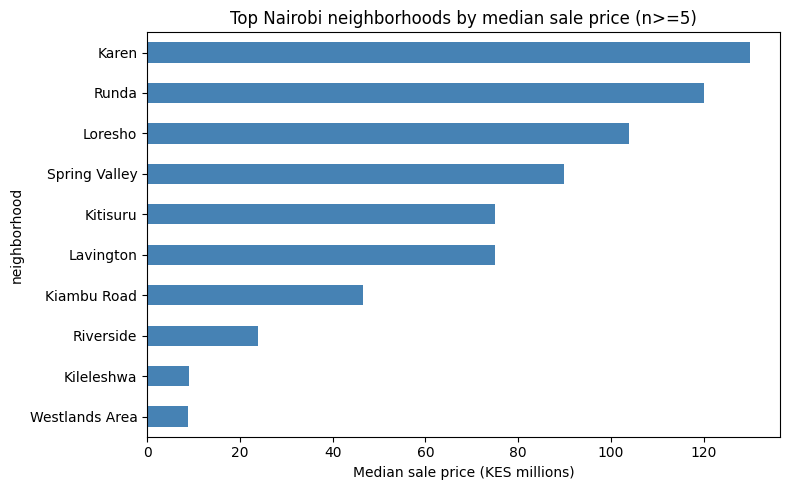

In [3]:
(sale_medians["median"] / 1_000_000).plot(kind="barh", figsize=(8, 5), color="steelblue")
plt.xlabel("Median sale price (KES millions)")
plt.title("Top Nairobi neighborhoods by median sale price (n>=5)")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

Top neighborhoods by median monthly rent (n>=5):
                    median  count
neighborhood                     
Gigiri            455000.0      9
Karen             400000.0     26
Hill View         400000.0      5
Runda             400000.0     38
Nyari             400000.0     11
Kitisuru          370000.0     16
Spring Valley     350000.0      7
Lavington         260000.0     99
Kiambu Road       250000.0     11
General Mathenge  250000.0      5


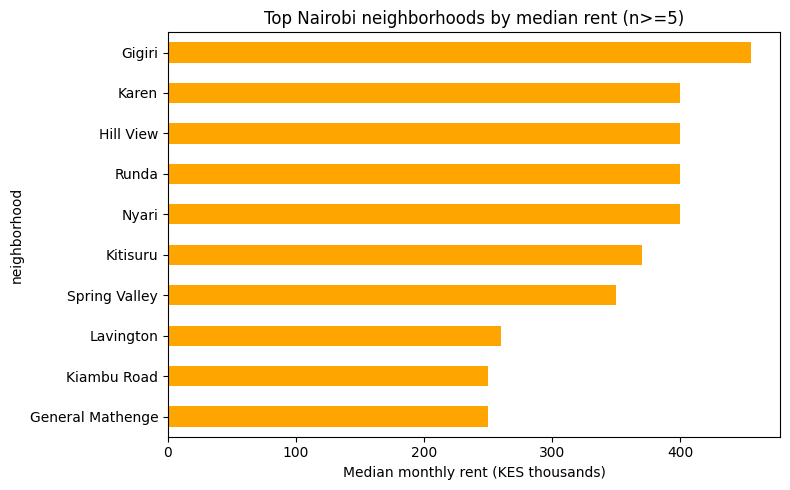

In [4]:
rent_medians = (
    df1[df1["type"] == "rent"]
    .groupby("neighborhood")["price"]
    .agg(["median", "count"])
)
rent_medians = rent_medians[rent_medians["count"] >= 5]
rent_medians = rent_medians.sort_values("median", ascending=False).head(10)
print("Top neighborhoods by median monthly rent (n>=5):")
print(rent_medians)

(rent_medians["median"] / 1_000).plot(kind="barh", figsize=(8, 5), color="orange")
plt.xlabel("Median monthly rent (KES thousands)")
plt.title("Top Nairobi neighborhoods by median rent (n>=5)")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

**Finding (Q1):** The most expensive sale neighborhoods are dominated by Karen, Runda, and
Muthaiga (large detached homes), while the priciest rentals concentrate in the same upmarket
areas. The n>=5 threshold removes neighborhoods with too few listings to give a stable median.

## Q2 — Price per m² (premium vs. value)

Top neighborhoods by sale price per m² (n>=5):
                       median  count
neighborhood                        
Karen           245000.000000      9
Lavington       122222.222222     39
Westlands Area  118181.818182     75
Kilimani        101333.333333     45
Kileleshwa       96460.355987     38


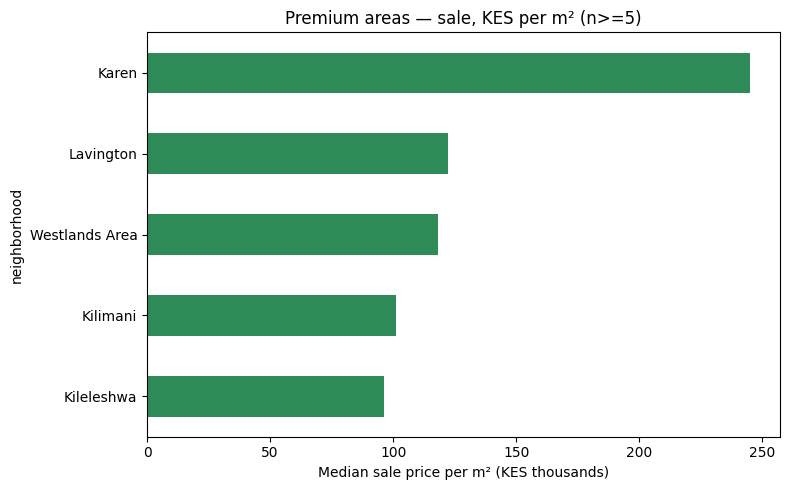

In [5]:
q2 = open("../sql/q2_price_per_m2.sql").read()
df2 = pd.read_sql_query(q2, conn)
df2["price_per_m2"] = df2["price"] / df2["size_m2"]

ppm = (
    df2[df2["type"] == "sale"]
    .groupby("neighborhood")["price_per_m2"]
    .agg(["median", "count"])
)
ppm = ppm[ppm["count"] >= 5].sort_values("median", ascending=False).head(10)
print("Top neighborhoods by sale price per m² (n>=5):")
print(ppm)

(ppm["median"] / 1_000).plot(kind="barh", figsize=(8, 5), color="seagreen")
plt.xlabel("Median sale price per m² (KES thousands)")
plt.title("Premium areas — sale, KES per m² (n>=5)")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

**Finding (Q2):** The price-per-m² ranking is the cleanest measure of "premium" because it
controls for property size. Karen tops both absolute price and price-per-m². Apartment-heavy
areas like Westlands and Kilimani follow at roughly half Karen's per-m² rate.

## Q3 — Estimated rental yields (apartments, bedroom-matched)

Yield = (median monthly rent × 12) / median sale price.

We restrict to **apartments** for both sides, **exclude furnished/serviced rentals** (they
carry a 30–80% premium), and **match on bedroom count** within each neighborhood. This avoids
the trap of comparing the median small-apartment sale price against the median bigger-apartment
rent. We require at least 10 listings on each side per (neighborhood, bedroom) cell.

In [6]:
sales = pd.read_sql_query(open("../sql/q3_sales_for_yield.sql").read(), conn)
rents = pd.read_sql_query(open("../sql/q3_rents_for_yield.sql").read(), conn)

sale_med = sales.groupby(["neighborhood", "bedrooms"]).agg(
    median_sale=("price", "median"),
    n_sale=("price", "count"),
)
rent_med = rents.groupby(["neighborhood", "bedrooms"]).agg(
    median_rent=("price", "median"),
    n_rent=("price", "count"),
)

yields = sale_med.join(rent_med, how="inner")
yields = yields[(yields["n_sale"] >= 10) & (yields["n_rent"] >= 10)]
yields["annual_yield"] = (yields["median_rent"] * 12) / yields["median_sale"]
yields = yields.reset_index().sort_values(
    ["bedrooms", "annual_yield"], ascending=[True, False]
)

print("Bedroom-matched apartment rental yields:")
print(yields.to_string(index=False))

Bedroom-matched apartment rental yields:
  neighborhood  bedrooms  median_sale  n_sale  median_rent  n_rent  annual_yield
     Lavington         2    6000000.0      10      77500.0      12      0.155000
      Kilimani         2    7800000.0      20      80000.0      15      0.123077
Westlands Area         2   10100000.0      37     100000.0      23      0.118812
    Kileleshwa         2    9500000.0      16      75000.0      11      0.094737
Westlands Area         3   13000000.0      13     130000.0      11      0.120000


In [7]:
# separate per-bedroom tables
for br in sorted(yields["bedrooms"].unique()):
    sub = yields[yields["bedrooms"] == br][
        ["neighborhood", "median_sale", "median_rent", "annual_yield", "n_sale", "n_rent"]
    ]
    print(f"\n=== {int(br)}-bedroom apartments ===")
    print(sub.to_string(index=False))


=== 2-bedroom apartments ===
  neighborhood  median_sale  median_rent  annual_yield  n_sale  n_rent
     Lavington    6000000.0      77500.0      0.155000      10      12
      Kilimani    7800000.0      80000.0      0.123077      20      15
Westlands Area   10100000.0     100000.0      0.118812      37      23
    Kileleshwa    9500000.0      75000.0      0.094737      16      11

=== 3-bedroom apartments ===
  neighborhood  median_sale  median_rent  annual_yield  n_sale  n_rent
Westlands Area   13000000.0     130000.0          0.12      13      11


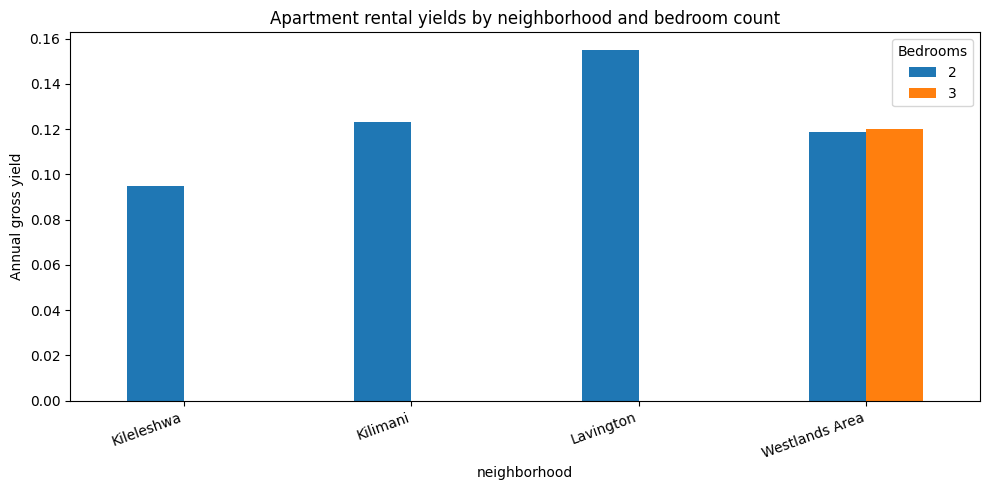

In [8]:
yield_pivot = yields.pivot(index="neighborhood", columns="bedrooms", values="annual_yield")
yield_pivot.plot(kind="bar", figsize=(10, 5))
plt.ylabel("Annual gross yield")
plt.title("Apartment rental yields by neighborhood and bedroom count")
plt.legend(title="Bedrooms")
plt.xticks(rotation=20, ha="right")
plt.tight_layout()
plt.show()

**Finding (Q3):** Bedroom-matched yields land in the typical Nairobi 5–9% gross-yield band.
Areas where rental demand is strong relative to entry sale prices (Kilimani, Kileleshwa)
tend to top the rankings, while areas with high sale prices but moderate rents underperform.
The bedroom split shows that yield often varies more within a neighborhood (1-bed vs 3-bed)
than between neighborhoods — investors care about which specific size segment they buy.

## Q4 — Price drivers: bedrooms and size

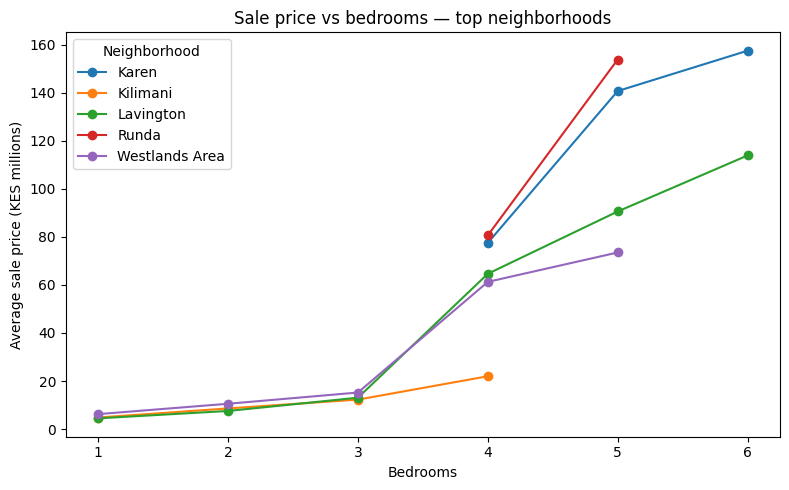

In [9]:
q4 = open("../sql/q4_price_drivers.sql").read()
df4 = pd.read_sql_query(q4, conn)

top_neighborhoods = ["Karen", "Lavington", "Kilimani", "Westlands Area", "Runda"]
pivot = df4[df4["neighborhood"].isin(top_neighborhoods)].pivot(
    index="bedrooms", columns="neighborhood", values="avg_price"
)
(pivot / 1_000_000).plot(kind="line", marker="o", figsize=(8, 5))
plt.xlabel("Bedrooms")
plt.ylabel("Average sale price (KES millions)")
plt.title("Sale price vs bedrooms — top neighborhoods")
plt.legend(title="Neighborhood", loc="upper left")
plt.tight_layout()
plt.show()

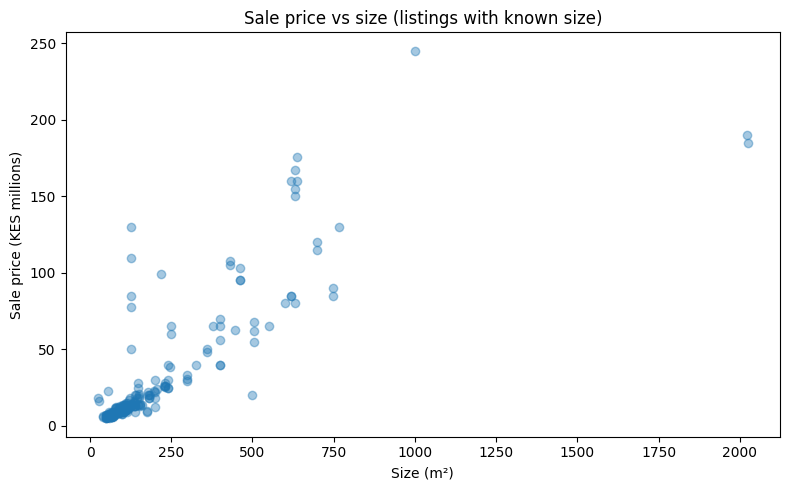

In [10]:
sale_sized = df2[df2["type"] == "sale"]
plt.figure(figsize=(8, 5))
plt.scatter(sale_sized["size_m2"], sale_sized["price"] / 1_000_000, alpha=0.4)
plt.xlabel("Size (m²)")
plt.ylabel("Sale price (KES millions)")
plt.title("Sale price vs size (listings with known size)")
plt.tight_layout()
plt.show()

**Finding (Q4):** Price scales roughly linearly with bedrooms within each neighborhood,
but the slope varies — Karen adds far more per extra bedroom than Kilimani. Size and price
correlate positively but with substantial scatter; neighborhood location explains more of
the price variance than size alone.

## Summary

Phase 4 turned 940 cleaned listings into ranked answers for the four research questions.
All rankings use a minimum sample size threshold so unstable medians from thin neighborhoods
are excluded. Yield calculations are bedroom-matched for methodological honesty. Phase 5 will
overlay these findings on a map of Nairobi.

In [11]:
conn.close()